In [1]:
import geopandas as gpd
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib
import requests
import country_converter as coco
import rasterio
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Latin Modern Roman'

### Load geodata

In [2]:
if not os.path.exists("Python/african_gdf.gpkg"):
    base_path = "C:/Users/bache/Documents/Studium&Beruf/Uni/7.Semester/BA/Data/Python/country_shapes"
    all_countries = []

    for file in os.listdir(base_path):
        if file.endswith(".gpkg"): 
            file_path = os.path.join(base_path, file)
            country_gdf = gpd.read_file(file_path)
            all_countries.append(country_gdf)

    african_gdf = pd.concat(all_countries, ignore_index=True)

    african_gdf.to_file("Python/african_gdf.gpkg")

else: african_gdf = gpd.read_file("Python/african_gdf.gpkg")

### Explore the Geodata

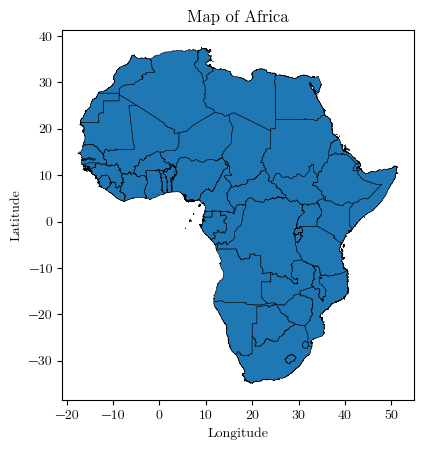

In [3]:
african_gdf.plot(edgecolor = "black",linewidth = 0.4)
plt.title("Map of Africa")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Event Data

In [4]:
if not os.path.exists("Python/event_data.csv"):
    event_data = pd.read_excel("Python/GEDEvent_v23_1.xlsx")

    event_data = event_data[event_data['region'] == 'Africa']
    columns_to_select = ['year', 'type_of_violence', 'conflict_name', 'side_a', 'side_b', 
                         'where_coordinates', 'adm_1', 'adm_2', 'latitude', 'longitude', 
                         'geom_wkt', 'priogrid_gid', 'country', 'date_start', 'date_end', 'best']
    event_data = event_data[columns_to_select]

    unique_countries = event_data['country'].unique()
    country_to_iso3 = coco.convert(names=unique_countries, to='ISO3', not_found=None)
    country_to_iso3_dict = dict(zip(unique_countries, country_to_iso3))

    event_data['GID_0'] = event_data['country'].map(country_to_iso3_dict)
    event_data = event_data.drop(["Unnamed: 0"], axis=1)
    
    event_data.to_csv("Python/event_data.csv", index=False)

else:
    event_data = pd.read_csv("Python/event_data.csv")
    event_data = event_data.drop(["Unnamed: 0"], axis=1)


african_gdf_w_events = pd.merge(event_data, african_gdf, on='GID_0', how='inner')

gdp_columns = [col for col in african_gdf_w_events.columns if col.startswith('gdp_')]
african_gdf_w_events['gdp_per_capita'] = african_gdf_w_events.apply(lambda row: row['gdp_' + str(row['year'])] if 'gdp_' + str(row['year']) in gdp_columns else None, axis=1)

african_gdf_w_events = african_gdf_w_events.drop(columns=gdp_columns)
gdf_events = gpd.GeoDataFrame(african_gdf_w_events, geometry=gpd.points_from_xy(african_gdf_w_events.longitude, african_gdf_w_events.latitude))


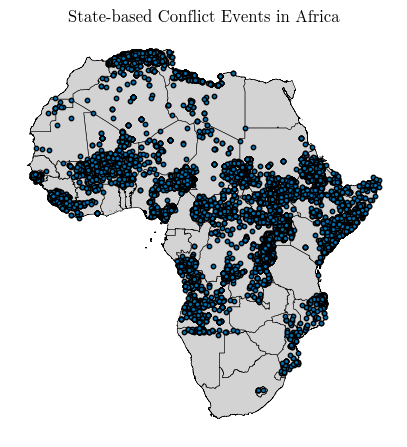

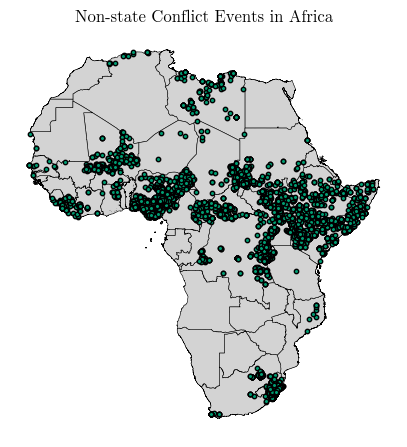

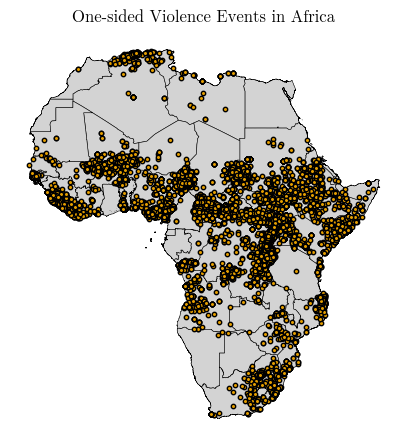

In [5]:
# verschiedene Konfliktarten
# State based
plot_appendix = gdf_events[gdf_events['best'] > 0]
plot_appendix1 = plot_appendix[plot_appendix['type_of_violence'] == 1]

fig, ax = plt.subplots(figsize=(5, 8))

african_gdf.plot(ax=ax, color='lightgrey', edgecolor="black", linewidth=0.4)
ax.scatter(plot_appendix1['longitude'], plot_appendix1['latitude'], edgecolor='k', s=10, color = '#0072B2')

plt.title('State-based Conflict Events in Africa')
ax.axis('off')

plt.savefig("Python/state-based.png",bbox_inches='tight', pad_inches=0.1)
plt.show()


# Non-state
plot_appendix = gdf_events[gdf_events['best'] > 0]
plot_appendix1 = plot_appendix[plot_appendix['type_of_violence'] == 2]

fig, ax = plt.subplots(figsize=(5, 8))

african_gdf.plot(ax=ax, color='lightgrey', edgecolor="black", linewidth=0.4)
ax.scatter(plot_appendix1['longitude'], plot_appendix1['latitude'], edgecolor='k', s=10, color = '#009E73')

plt.title('Non-state Conflict Events in Africa')
ax.axis('off')

plt.savefig("Python/non-state.png",bbox_inches='tight', pad_inches=0.1)
plt.show()


# One-sided
plot_appendix = gdf_events[gdf_events['best'] > 0]
plot_appendix1 = plot_appendix[plot_appendix['type_of_violence'] == 3]

fig, ax = plt.subplots(figsize=(5, 8))

african_gdf.plot(ax=ax, color='lightgrey', edgecolor="black", linewidth=0.4)
ax.scatter(plot_appendix1['longitude'], plot_appendix1['latitude'], edgecolor='k', s=10, color = "#E69F00")

plt.title('One-sided Violence Events in Africa')
ax.axis('off')

plt.savefig("Python/one-sided.png",bbox_inches='tight', pad_inches=0.1)
plt.show()


### Road network data

Anzahl der Bänder: 71
Statistiken für Band 71 nach Ersetzen der nodata-Werte: min=0.0, max=127.79475402832031


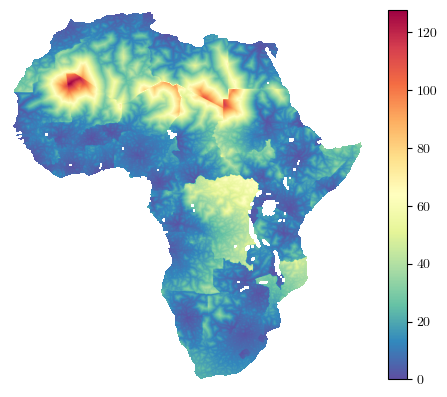

In [6]:
# Beispielsvisualisierung für 2016 (National Capital)
year = 2016
band = year - 1946 + 1

in_img = 'Python/time2natcap_1946_2016_dynroads.tif'

with rasterio.open(in_img) as ds:
    print(f"Anzahl der Bänder: {ds.count}")
    band_data = ds.read(band)
    
    band_data = band_data.astype('float32')
    nodata_value = ds.nodatavals[0]
    if np.isfinite(nodata_value):
        band_data[band_data == nodata_value] = np.nan
    print(f"Statistiken für Band {band} nach Ersetzen der nodata-Werte: min={np.nanmin(band_data)}, max={np.nanmax(band_data)}")
    
    plt.imshow(band_data, cmap="Spectral_r")
    plt.colorbar()
    plt.xticks([]) 
    plt.yticks([])
    plt.ylim(1730, 0) 
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.show()

In [6]:
# Berechnung von Travel Time to National Capital 
def calculate_remoteness_value(row, raster, start_year):
    year = row['year']
    band_number = min(year - start_year + 1, raster.count)
    row_idx, col_idx = raster.index(row['longitude'], row['latitude'])
    band_data = raster.read(band_number)
    value = band_data[row_idx, col_idx]
    
    return value if value != raster.nodatavals[0] else np.nan

# Berechnung von Travel Time to National Capital mit 10 Jahren lagged (am Ende nicht in der BA verwendet)
def calculate_lagged_value(row, raster, start_year, max_band_number):
    year = row['year']
    if year > start_year + 10:
        lagged_year = year - 10
        lagged_band_number = min(lagged_year - start_year + 1, max_band_number)
        row_idx, col_idx = raster.index(row['longitude'], row['latitude'])
        lagged_band_data = raster.read(lagged_band_number)
        lagged_value = lagged_band_data[row_idx, col_idx]

        return lagged_value if lagged_value != raster.nodatavals[0] else np.nan
    return np.nan

if not os.path.exists("Python/gdf_events_and_roads.geojson"):
    gdf_e_r = gpd.read_file("Python/gdf_events.geojson")
    gdf_e_r['remoteness_reg'] = np.nan
    gdf_e_r['remoteness_nat'] = np.nan
    gdf_e_r['lagged_remoteness_reg'] = np.nan
    gdf_e_r['lagged_remoteness_nat'] = np.nan

    raster_reg = rasterio.open('Python/time2regcap_1945_2016_dynroads.tif')
    raster_nat = rasterio.open('Python/time2natcap_1946_2016_dynroads.tif')

    for index, row in gdf_e_r.iterrows():
        gdf_e_r.at[index, 'remoteness_reg'] = calculate_remoteness_value(row, raster_reg, 1945)
        gdf_e_r.at[index, 'remoteness_nat'] = calculate_remoteness_value(row, raster_nat, 1946)
        gdf_e_r.at[index, 'lagged_remoteness_reg'] = calculate_lagged_value(row, raster_reg, 1945, raster_reg.count)
        gdf_e_r.at[index, 'lagged_remoteness_nat'] = calculate_lagged_value(row, raster_nat, 1946, raster_nat.count)

    raster_reg.close()
    raster_nat.close()

else: 
    gdf_e_r = gpd.read_file("Python/gdf_events_and_roads.geojson")

gdf_e_r['type_of_violence'] = gdf_e_r['type_of_violence'].map({
    1: 'state-based',
    2: 'non-state',
    3: 'one-sided'
})

gdf_e_r.rename(columns={'best': 'fatalities'}, inplace=True)
gdf_e_r = gdf_e_r.drop(["Gini","gdp_per_capita","COUNTRY"],axis=1)


### Control Variables

In [8]:
static_controls = pd.read_csv("Python/prio_static.csv")
static_controls = static_controls.drop(["row","xcoord","col","ycoord"], axis=1)

year_controls = pd.read_csv("Python/prio_yearly.csv")

static_controls.rename(columns={'gid': 'priogrid_gid'}, inplace=True)
year_controls.rename(columns={'gid': 'priogrid_gid'}, inplace=True)

year_controls.sort_values(by=['priogrid_gid', 'year'], inplace=True)
final_data = pd.merge(gdf_e_r, static_controls, on='priogrid_gid', how='left')
final_data = pd.merge(final_data, year_controls, on=['priogrid_gid', 'year'], how='left')

final_data = final_data.groupby('priogrid_gid').ffill()
final_data["pop_density"] = final_data["pop_gpw_sum"] / final_data["landarea"]
final_data = final_data.drop(["pop_gpw_sum"], axis =1)